# Importing required libraries for data analysis, visualization, and machine learning

In [ ]:
# Suppress warnings for cleaner output (used only for presentation clarity)
import warnings
warnings.filterwarnings("ignore")

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Machine Learning models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation metrics (IMPORTANT)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Reading the primary dataset (Crop Recommendation Dataset)


In [2]:
# Reading Dataset 1: Crop Recommendation (Main ML dataset)
df_main = pd.read_csv("./Dataset/Crop_recommendation.csv")

# Reading Dataset 2: India Agriculture Production
df_india = pd.read_csv("./Dataset/India Agriculture Crop Production.csv")

# Reading Dataset 3: Commodity / Market Dataset
df_market = pd.read_csv("./Dataset/RS_Session_266_AU_121_B_i.csv")

# Display first 5 rows of all datasets
print("🔹 Dataset 1: Crop Recommendation")
display(df_main.head())

print("\n🔹 Dataset 2: India Agriculture Production")
display(df_india.head())

print("\n🔹 Dataset 3: Market Dataset")
display(df_market.head())

🔹 Dataset 1: Crop Recommendation


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice



🔹 Dataset 2: India Agriculture Production


,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield
0,Andaman and Nicobar Islands,NICOBARS,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541
1,Andaman and Nicobar Islands,NICOBARS,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803
2,Andaman and Nicobar Islands,NICOBARS,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358
3,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000
4,Andaman and Nicobar Islands,SOUTH ANDAMANS,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296



🔹 Dataset 3: Market Dataset


,Sl. No.,Commodities,KMS 2013-14,KMS 2014-15,KMS 2015-16,KMS 2016-17,KMS 2017-18,KMS 2018-19,KMS 2019-20,KMS 2020-21,KMS 2021-22,KMS 2022-23,KMS 2023-24,KMS 2024-25,% increase 201314 to 2024-25
0,1,Paddy (Common),1310,1360,1410,1470,1550,1750,1815,1868,1940,2040,2183,2300,75.57
1,2,Paddy (Grade A),1345,1400,1450,1510,1590,1770,1835,1888,1960,2060,2203,2320,72.49
2,3,Jowar (Hybrid),1500,1530,1570,1625,1700,2430,2550,2620,2738,2970,3180,3371,124.73
3,4,Jowar (Maldandi),1520,1550,1590,1650,1725,2450,2570,2640,2758,2990,3225,3421,125.07
4,5,Bajra,1250,1250,1275,1330,1425,1950,2000,2150,2250,2350,2500,2625,110.00


In [3]:
print("🔹 Main Dataset")
display(df_main.head(10))

print("🔹 India Dataset")
display(df_india.head(10))

print("🔹 Market Dataset")
display(df_market.head(10))

🔹 Main Dataset


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


🔹 India Dataset


,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield
0,Andaman and Nicobar Islands,NICOBARS,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541
1,Andaman and Nicobar Islands,NICOBARS,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803
2,Andaman and Nicobar Islands,NICOBARS,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358
3,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000
4,Andaman and Nicobar Islands,SOUTH ANDAMANS,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296
5,Andaman and Nicobar Islands,SOUTH ANDAMANS,Arecanut,2003-04,Whole Year,3118.0,Hectare,5182.0,Tonnes,1.661963
6,Andaman and Nicobar Islands,NICOBARS,Banana,2002-03,Whole Year,213.0,Hectare,1278.0,Tonnes,6.000000
7,Andaman and Nicobar Islands,NICOBARS,Banana,2003-04,Whole Year,266.0,Hectare,1763.0,Tonnes,6.627820
8,Andaman and Nicobar Islands,SOUTH ANDAMANS,Banana,2002-03,Whole Year,1524.0,Hectare,10882.0,Tonnes,7.140420
9,Andaman and Nicobar Islands,SOUTH ANDAMANS,Banana,2003-04,Whole Year,1530.0,Hectare,11558.0,Tonnes,7.554248


🔹 Market Dataset


,Sl. No.,Commodities,KMS 2013-14,KMS 2014-15,KMS 2015-16,KMS 2016-17,KMS 2017-18,KMS 2018-19,KMS 2019-20,KMS 2020-21,KMS 2021-22,KMS 2022-23,KMS 2023-24,KMS 2024-25,% increase 201314 to 2024-25
0,1,Paddy (Common),1310,1360,1410,1470,1550,1750,1815,1868,1940,2040,2183,2300,75.57
1,2,Paddy (Grade A),1345,1400,1450,1510,1590,1770,1835,1888,1960,2060,2203,2320,72.49
2,3,Jowar (Hybrid),1500,1530,1570,1625,1700,2430,2550,2620,2738,2970,3180,3371,124.73
3,4,Jowar (Maldandi),1520,1550,1590,1650,1725,2450,2570,2640,2758,2990,3225,3421,125.07
4,5,Bajra,1250,1250,1275,1330,1425,1950,2000,2150,2250,2350,2500,2625,110.00
5,6,Ragi,1500,1550,1650,1725,1900,2897,3150,3295,3377,3578,3846,4290,186.00
6,7,Maize,1310,1310,1325,1365,1425,1700,1760,1850,1870,1962,2090,2225,69.85
7,8,Arhar(Tur),4300,4350,4625,5050,5450,5675,5800,6000,6300,6600,7000,7550,75.58
8,9,Moong,4500,4600,4850,5225,5575,6975,7050,7196,7275,7755,8558,8682,92.93
9,10,Urad,4300,4350,4625,5000,5400,5600,5700,6000,6300,6600,6950,7400,72.09


In [4]:
print("📊 Dataset Shapes:")

print("Main Dataset:", df_main.shape)
print("India Dataset:", df_india.shape)
print("Market Dataset:", df_market.shape)

📊 Dataset Shapes:
Main Dataset: (2200, 8)
India Dataset: (345407, 10)
Market Dataset: (17, 15)


In [5]:
print("🔹 Missing Values in Main Dataset")
print(df_main.isnull().sum())

print("\n🔹 Missing Values in India Dataset")
print(df_india.isnull().sum())

print("\n🔹 Missing Values in Market Dataset")
print(df_market.isnull().sum())

🔹 Missing Values in Main Dataset
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

🔹 Missing Values in India Dataset
State                  0
District               0
Crop                  32
Year                   0
Season                 1
Area                  33
Area Units             0
Production          4993
Production Units       0
Yield                 33
dtype: int64

🔹 Missing Values in Market Dataset
Sl. No.                         0
Commodities                     0
KMS 2013-14                     0
KMS 2014-15                     0
KMS 2015-16                     0
KMS 2016-17                     0
KMS 2017-18                     0
KMS 2018-19                     0
KMS 2019-20                     0
KMS 2020-21                     0
KMS 2021-22                     0
KMS 2022-23                     0
KMS 2023-24                     0
KMS 2024-25                     0
% increa

# Exploratory Data Analysis (EDA)


1. Nitrogen (N) Distribution

   This plot shows the distribution of Nitrogen values in the dataset. Nitrogen is a key nutrient affecting crop growth and productivity.

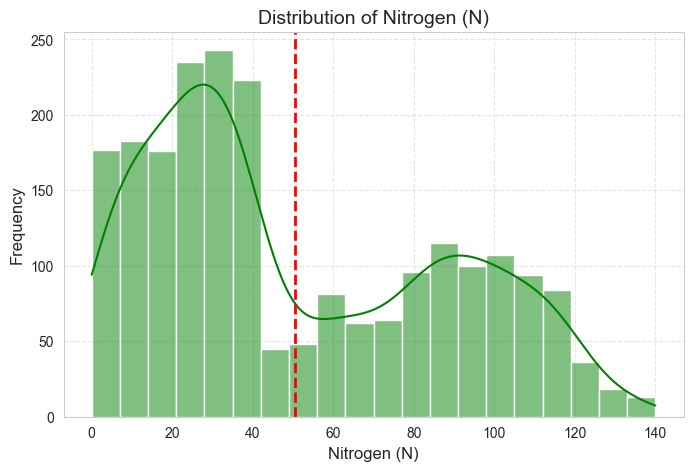

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df_main['N'], bins=20, kde=True, color='green')
plt.axvline(df_main['N'].mean(), color='red', linestyle='dashed', linewidth=2)
plt.title('Distribution of Nitrogen (N)', fontsize=14)
plt.xlabel('Nitrogen (N)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

 2. Potassium (K) Distribution

Potassium is another essential nutrient that supports plant growth and disease resistance. This visualization shows how potassium values are distributed in the dataset.

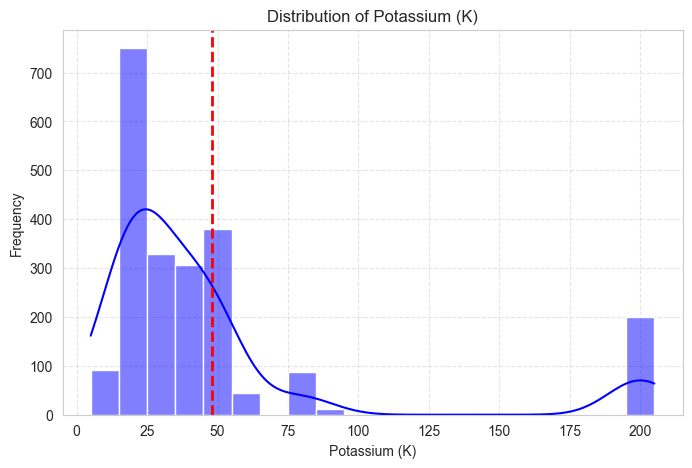

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df_main['K'], bins=20, kde=True, color='blue')
plt.axvline(df_main['K'].mean(), color='red', linestyle='dashed', linewidth=2)
plt.title('Distribution of Potassium (K)')
plt.xlabel('Potassium (K)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Phosphorus (P) Distribution

Phosphorus is essential for root development and energy transfer in plants. This graph shows its distribution in the dataset.

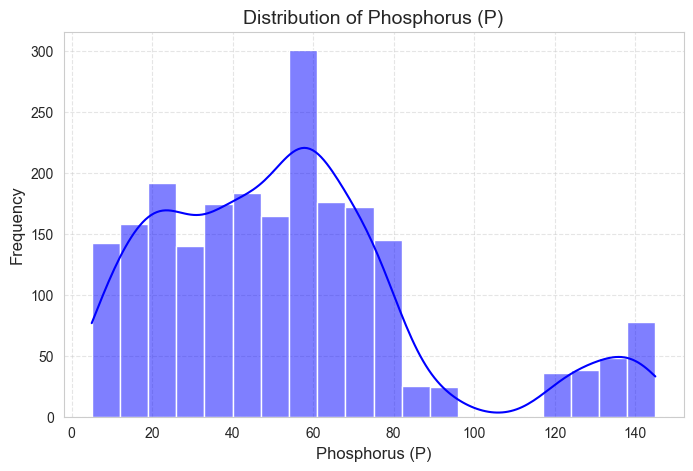

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df_main['P'], bins=20, kde=True, color='blue')
plt.title('Distribution of Phosphorus (P)', fontsize=14)
plt.xlabel('Phosphorus (P)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Temperature Distribution

Temperature is an environmental factor affecting crop growth. This graph shows how temperature values are distributed in the dataset.

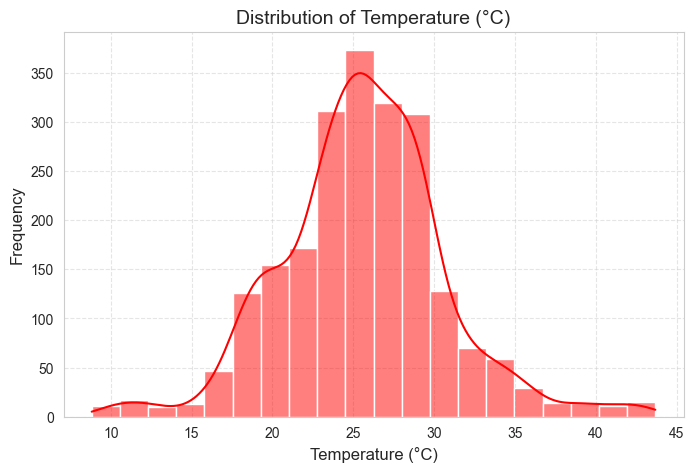

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df_main['temperature'], bins=20, kde=True, color='red')
plt.title('Distribution of Temperature (°C)', fontsize=14)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Humidity Distribution

Humidity is an important environmental factor that influences crop growth, transpiration, and water retention in plants.  
This graph shows how humidity values are distributed across the dataset, helping identify common environmental conditions under which different crops grow.

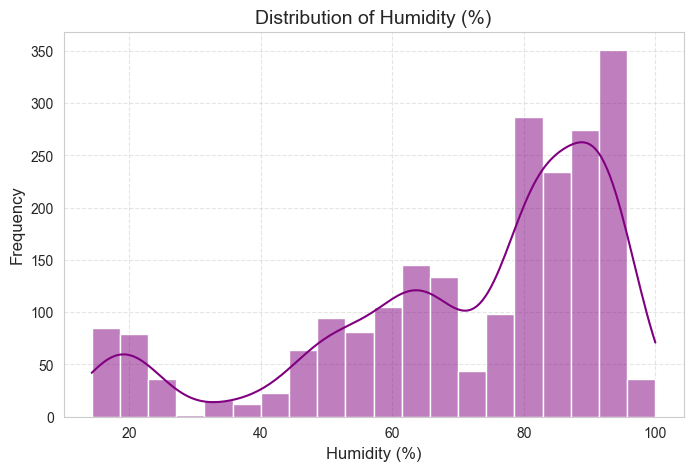

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df_main['humidity'], bins=20, kde=True, color='purple')
plt.title('Distribution of Humidity (%)', fontsize=14)
plt.xlabel('Humidity (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

pH Distribution

pH is an important soil parameter that affects nutrient availability and crop suitability.This analysis shows how pH values are distributed across the dataset, helping understand soil conditions for different crops.

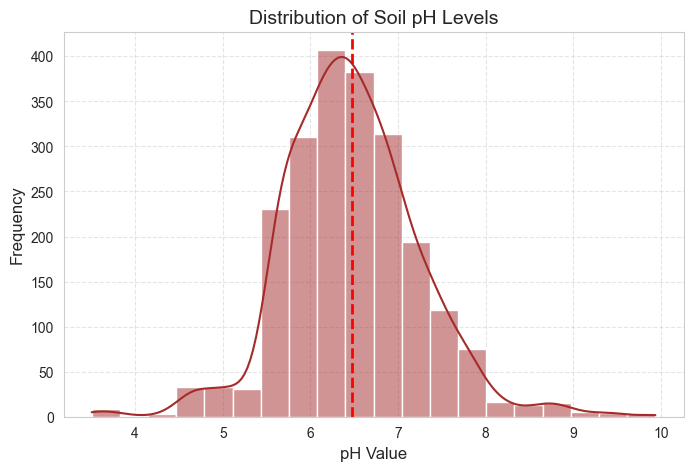

In [11]:
# pH Distribution Plot

plt.figure(figsize=(8, 5))

# Histogram with KDE curve
sns.histplot(df_main['ph'], bins=20, kde=True, color='brown')

# Mean line (important for analysis)
plt.axvline(df_main['ph'].mean(), color='red', linestyle='dashed', linewidth=2)

# Titles and labels
plt.title('Distribution of Soil pH Levels', fontsize=14)
plt.xlabel('pH Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Grid for better readability
plt.grid(True, linestyle='--', alpha=0.5)

# Show plot
plt.show()

Rainfall Distribution

Rainfall is a critical environmental factor that influences soil moisture and crop growth.This graph shows the distribution of rainfall values in the dataset, helping understand water availability for different crops.

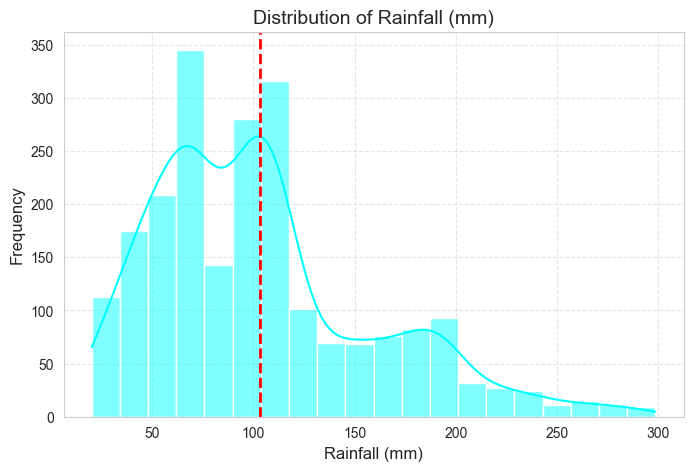

In [12]:
# Rainfall Distribution Plot

plt.figure(figsize=(8, 5))

# Histogram with KDE curve
sns.histplot(df_main['rainfall'], bins=20, kde=True, color='cyan')

# Mean line (important)
plt.axvline(df_main['rainfall'].mean(), color='red', linestyle='dashed', linewidth=2)

# Titles and labels
plt.title('Distribution of Rainfall (mm)', fontsize=14)
plt.xlabel('Rainfall (mm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Show plot
plt.show()

### Combined Boxplot for Feature Analysis

This boxplot visualizes the distribution of all numerical features and helps in identifying outliers and variability in the dataset.

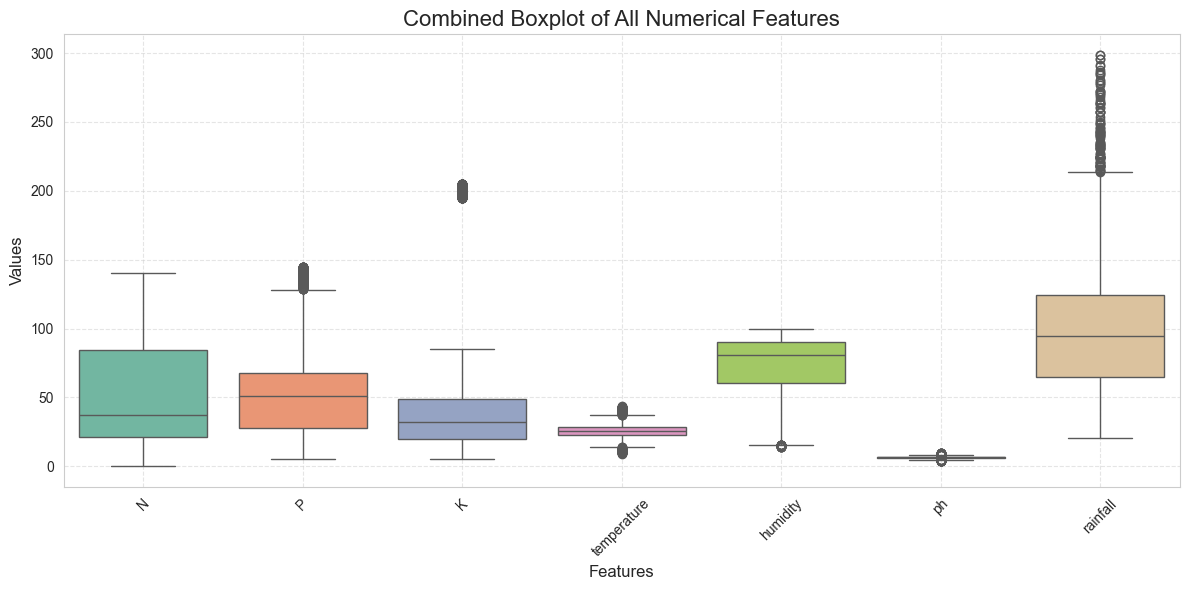

In [13]:
# Features list
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

plt.figure(figsize=(12, 6))

# Boxplot
sns.boxplot(data=df_main[features], palette='Set2')

# Titles and labels
plt.title('Combined Boxplot of All Numerical Features', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Values', fontsize=12)

# Styling
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

# Show plot
plt.show()

PAIR  PLOT

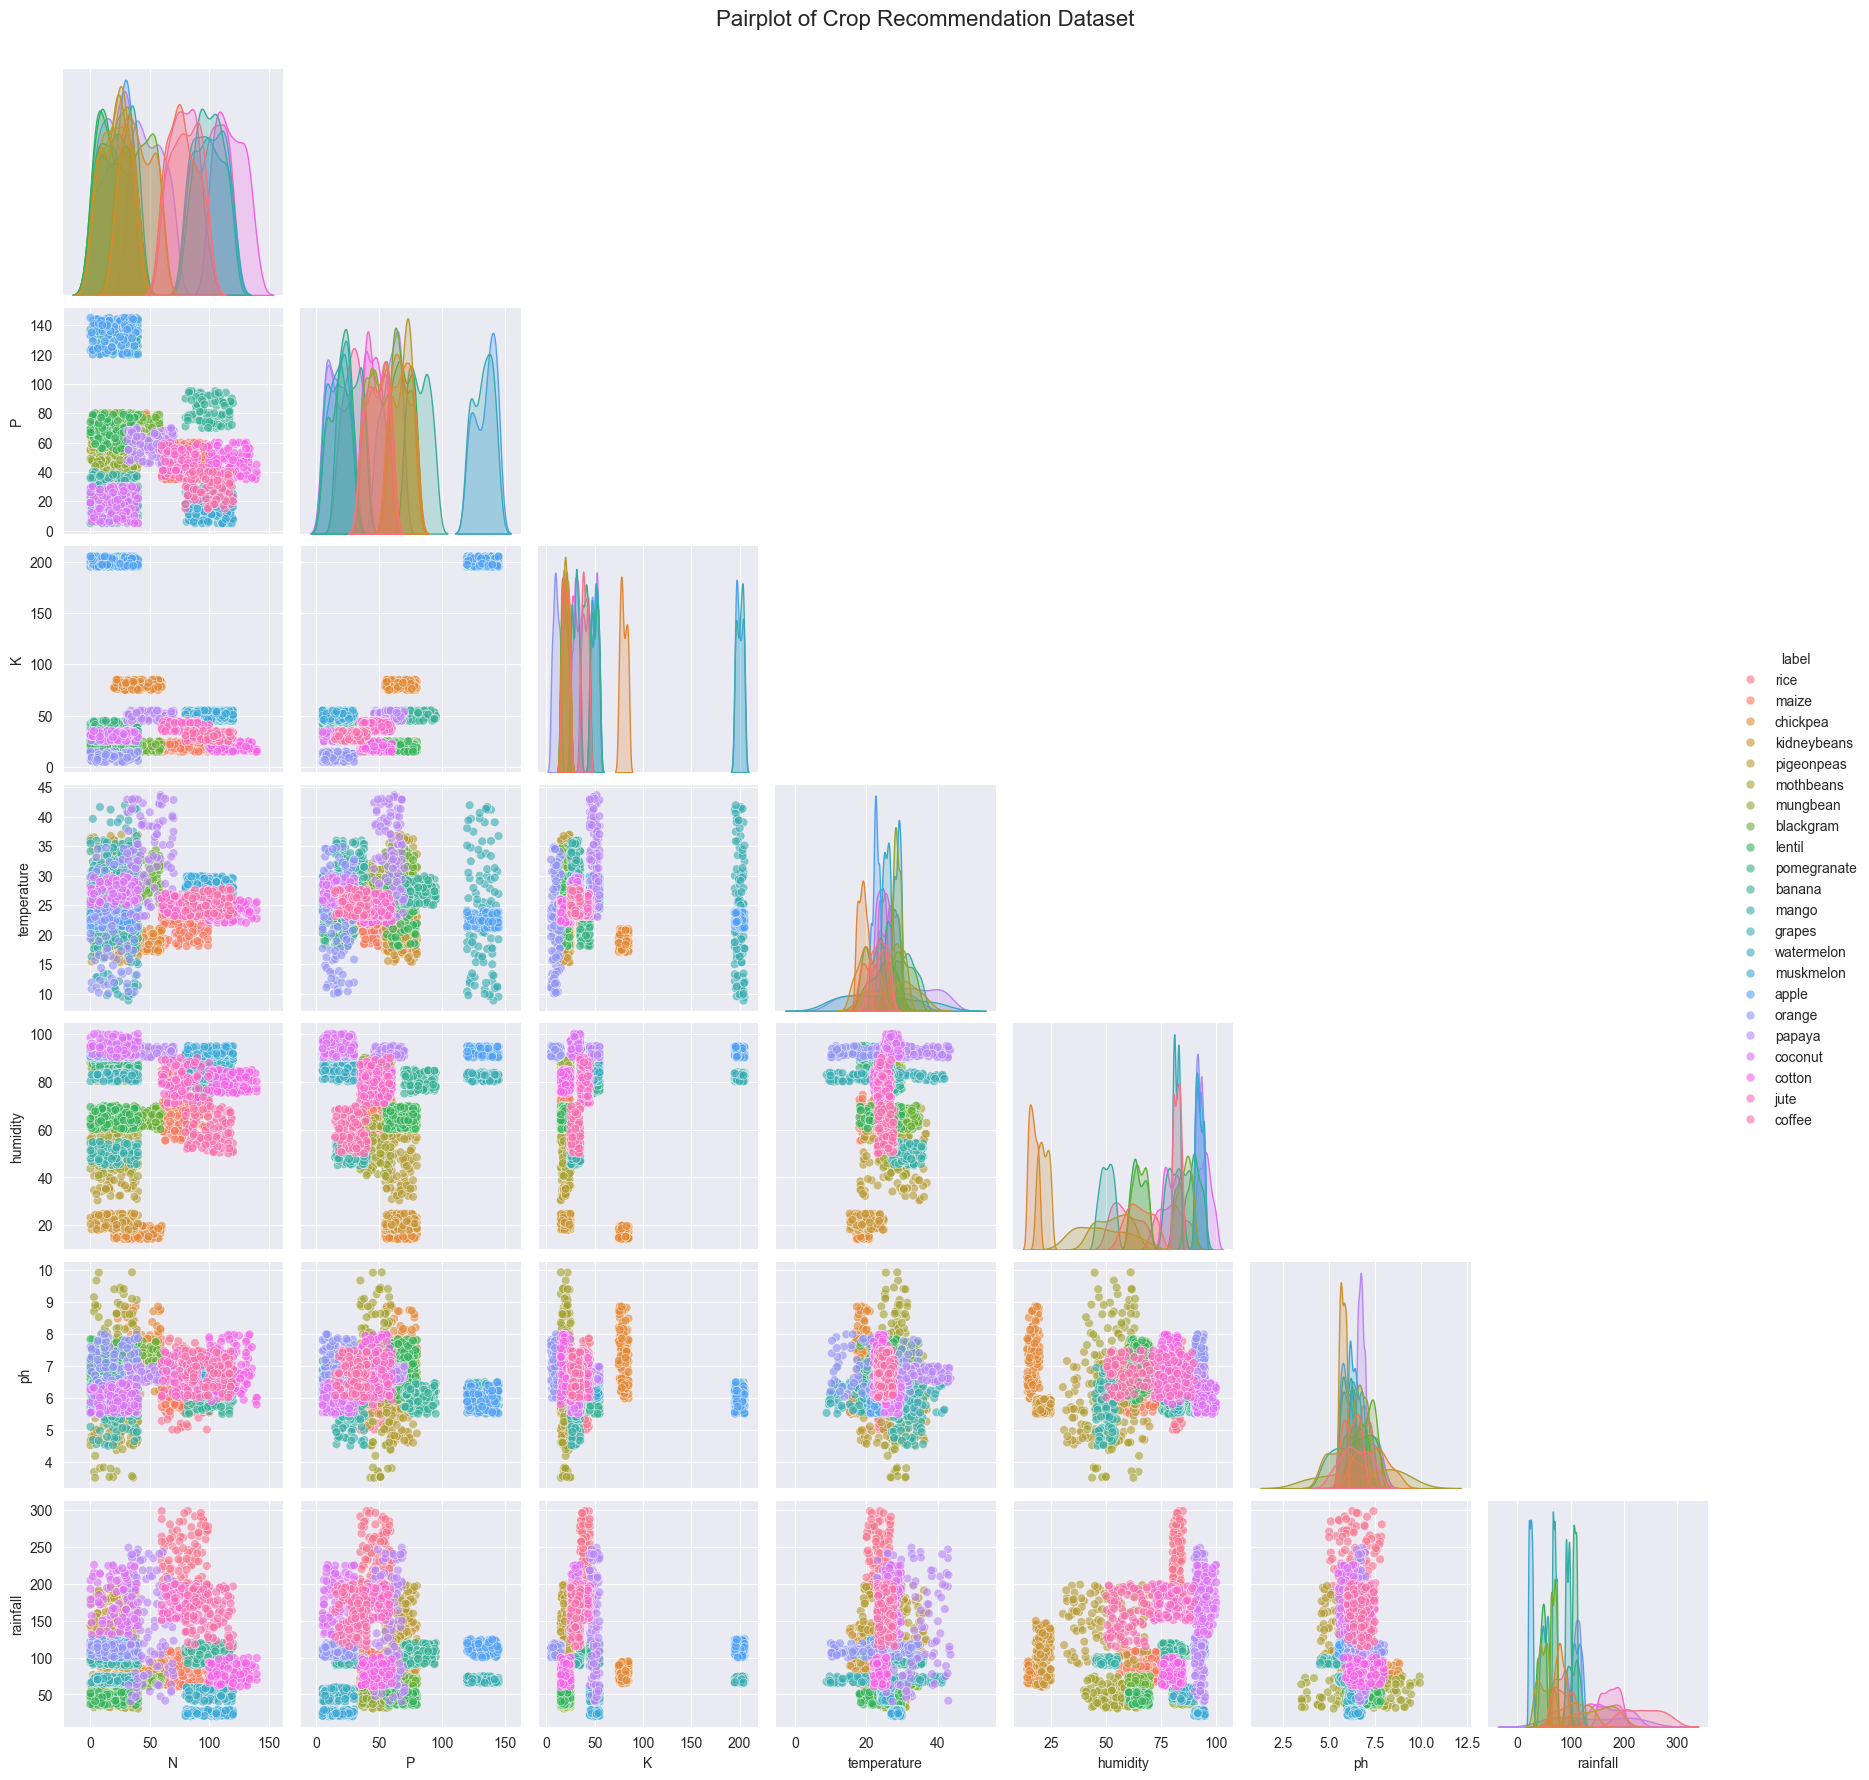

In [14]:
# Set style
sns.set_style('darkgrid')

# Select relevant features
selected_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

# Create pairplot
pair_plot = sns.pairplot(df_main[selected_features], 
                         hue='label', 
                         palette='husl', 
                         corner=True, 
                         plot_kws={'alpha': 0.6, 's': 40})

# Add title
pair_plot.fig.suptitle('Pairplot of Crop Recommendation Dataset', 
                       fontsize=16, 
                       y=1.02)

plt.show()

### Correlation Heatmap


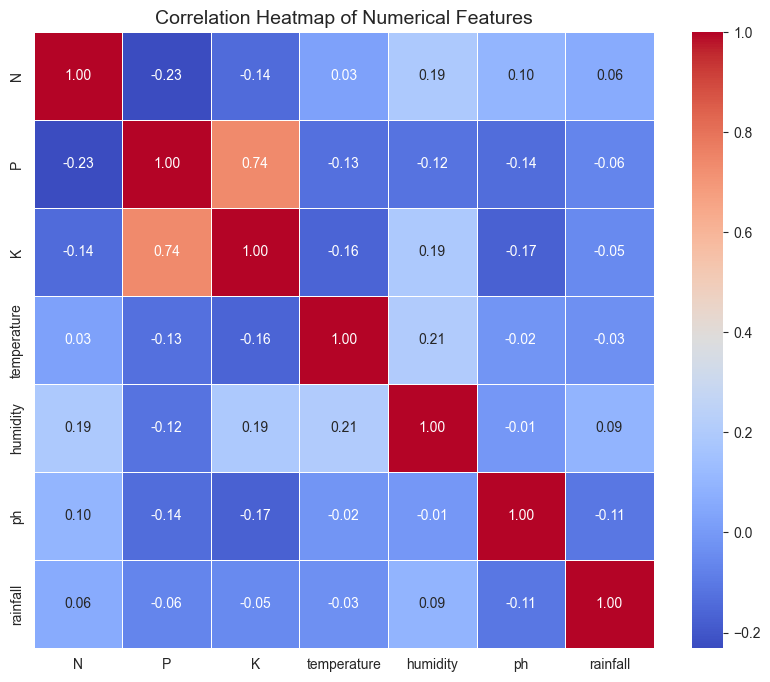

In [15]:
# Selecting only numerical columns 
numerical_data = df_main.select_dtypes(include=['float64', 'int64'])

# Correlation matrix
corr_matrix = numerical_data.corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.show()

Displot for Rainfall Levels

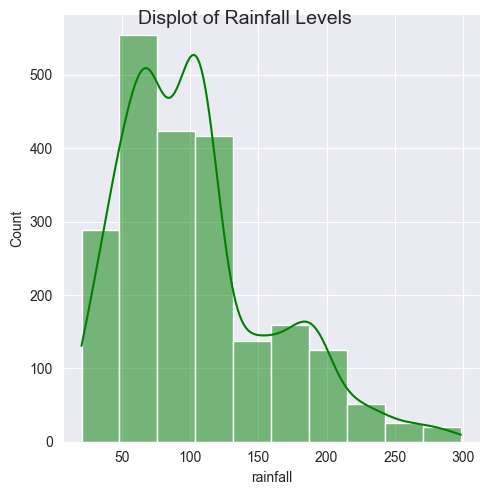

In [16]:
g = sns.displot(df_main['rainfall'], 
                kde=True, 
                bins=10, 
                color='green')

g.fig.suptitle('Displot of Rainfall Levels', fontsize=14)

plt.show()

### Count Plot of Crop Types

This plot shows the distribution of different crop labels in the dataset.  
It helps in understanding whether the dataset is balanced or imbalanced across different crop classes.

A balanced dataset ensures better model performance and reduces bias during prediction.

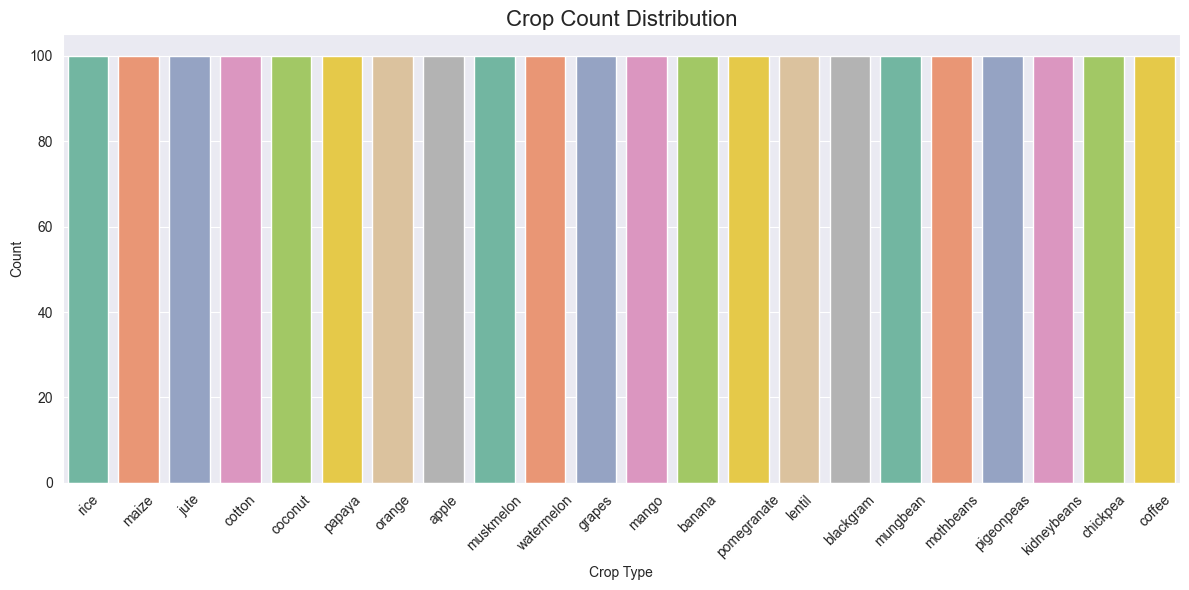

In [17]:
# Count Plot of Crop Types

plt.figure(figsize=(12, 6))

sns.countplot(x='label', 
              data=df_main, 
              palette='Set2', 
              order=df_main['label'].value_counts().index)

plt.title('Crop Count Distribution', fontsize=16)
plt.xlabel('Crop Type')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Violin Plot – Feature Distribution by Crop

The violin plot shows the distribution of numerical features across different crop types.  
It combines boxplot and KDE, providing both summary statistics and distribution shape.

This helps in understanding how features like Nitrogen, pH, and rainfall vary across different crops.

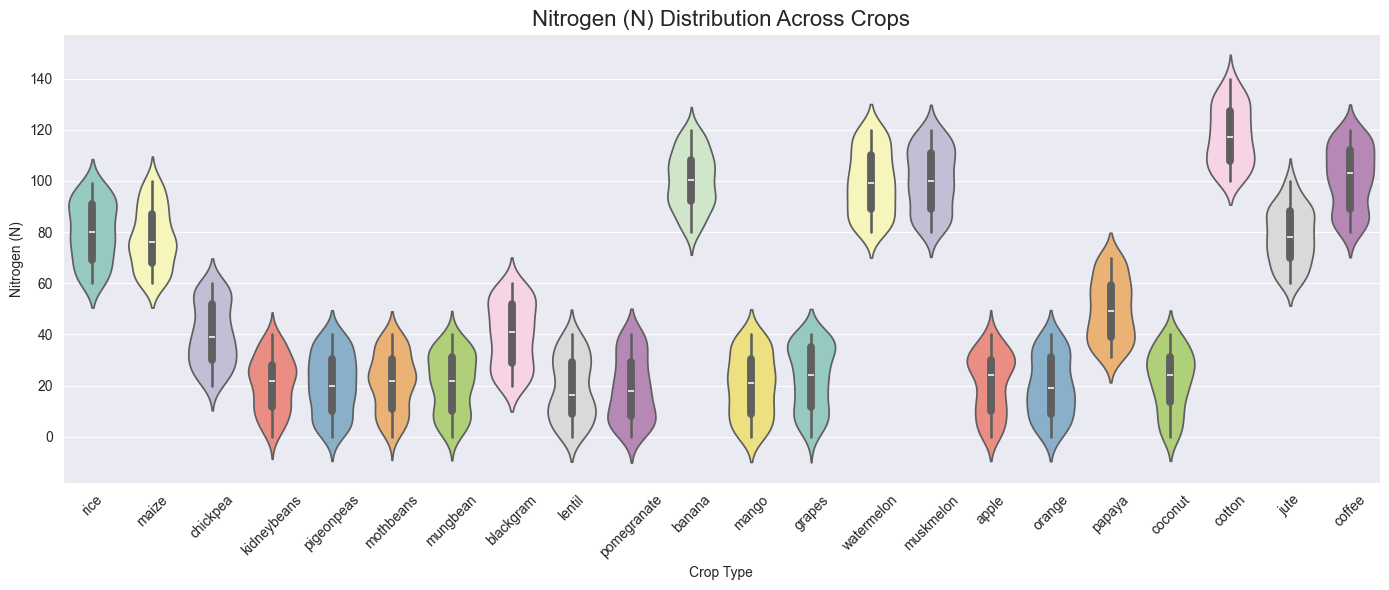

In [18]:
# Violin Plot – Nitrogen Distribution Across Crops

plt.figure(figsize=(14, 6))

sns.violinplot(x='label', 
               y='N', 
               data=df_main, 
               palette='Set3')

plt.title('Nitrogen (N) Distribution Across Crops', fontsize=16)
plt.xlabel('Crop Type')
plt.ylabel('Nitrogen (N)')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Swarm Plot – Detailed Data Spread

The swarm plot shows the distribution of data points for a specific feature across different crop types.  
It provides a detailed view of individual data points, helping identify clusters and variations.

However, for large datasets, swarm plots can become dense, so they are used selectively.

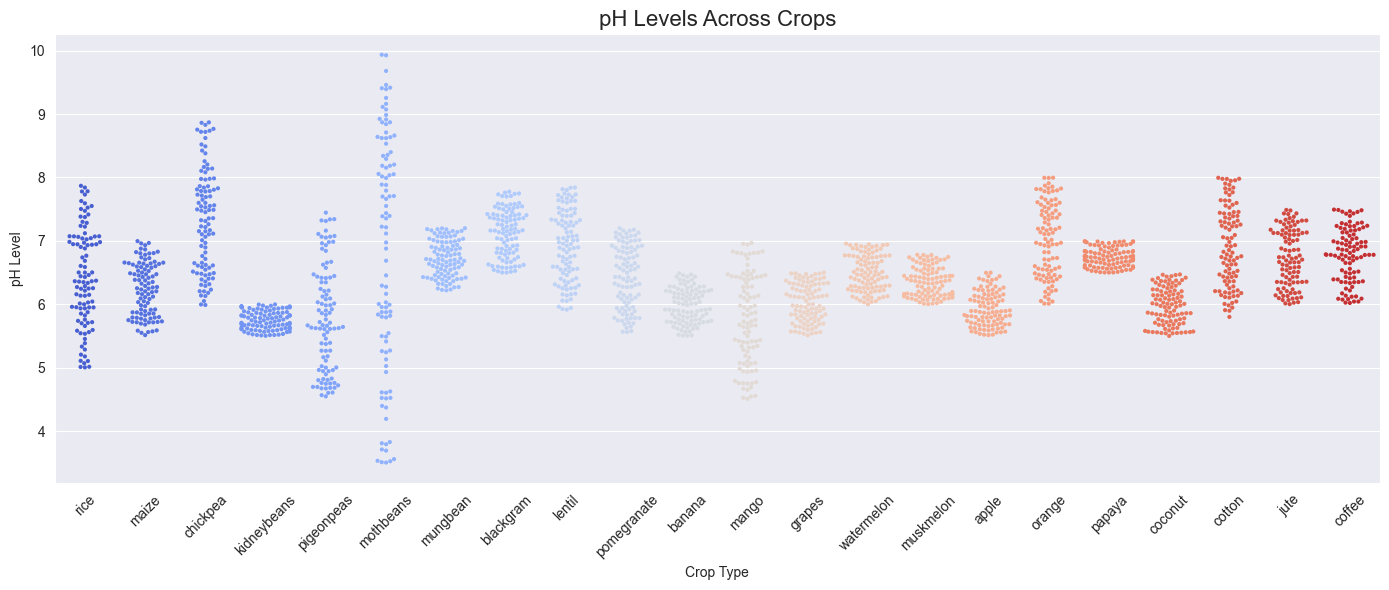

In [19]:
# Swarm Plot – pH Levels Across Crops

plt.figure(figsize=(14, 6))

sns.swarmplot(x='label', 
              y='ph', 
              data=df_main, 
              palette='coolwarm', 
              size=3)   # smaller size to avoid clutter

plt.title('pH Levels Across Crops', fontsize=16)
plt.xlabel('Crop Type')
plt.ylabel('pH Level')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Agricultural Production Analysis (India Dataset)

This dataset is used to analyze crop production trends across different states in India.  
It helps in understanding which crops are widely cultivated and how production varies regionally.

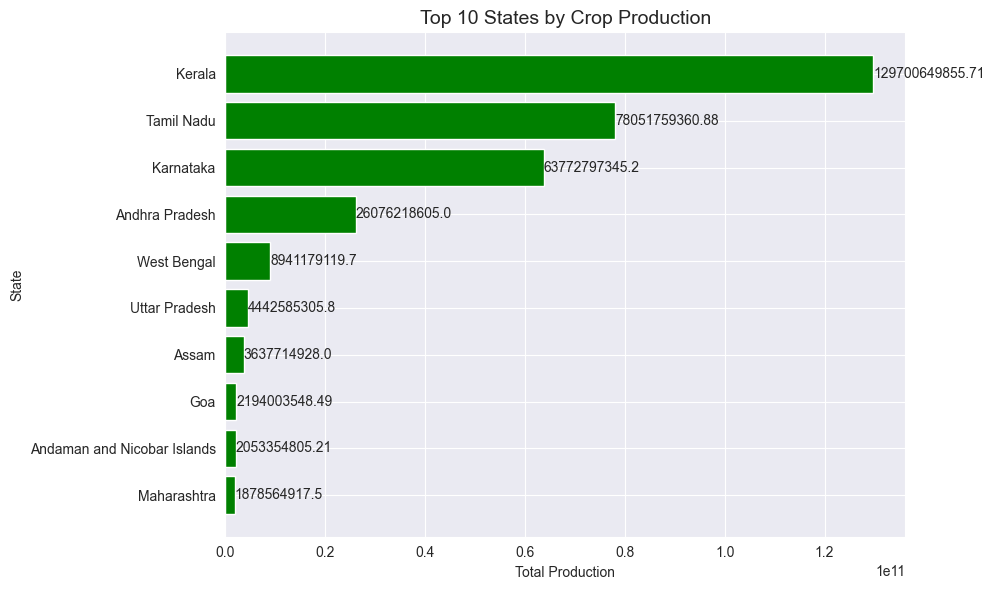

In [20]:
# Top 10 States by Production (Improved Visualization)

top_states = df_india.groupby('State')['Production'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10,6))

bars = plt.barh(top_states.index, top_states.values, color='green')

plt.title("Top 10 States by Crop Production", fontsize=14)
plt.xlabel("Total Production")
plt.ylabel("State")

# Add values on bars
for i, v in enumerate(top_states.values):
    plt.text(v, i, str(round(v, 2)), va='center')

plt.tight_layout()
plt.show()

### Year-wise Production Trend

This graph shows the trend of total agricultural production over different years.  
It helps analyze how crop production has changed over time and identifies growth or decline patterns.

Such analysis is useful for understanding long-term agricultural performance and planning future strategies.

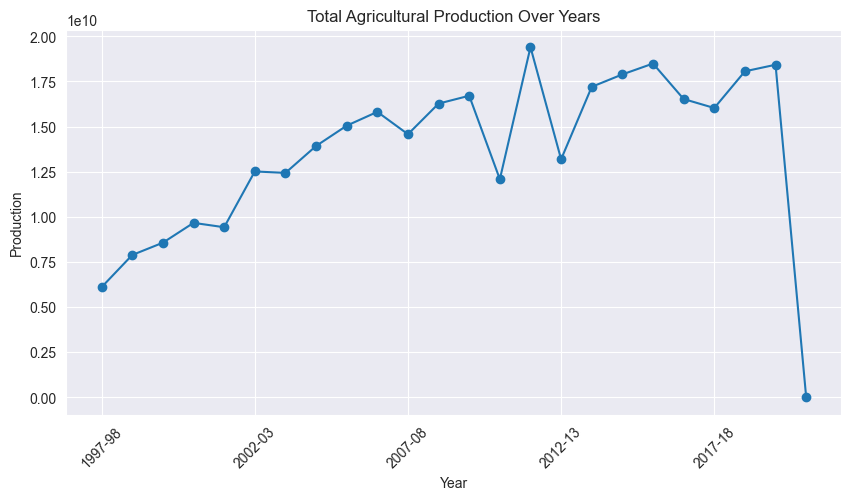

In [21]:
# Production Trend Over Years

yearly_production = df_india.groupby('Year')['Production'].sum()

plt.figure(figsize=(10,5))
yearly_production.plot(marker='o')

plt.title("Total Agricultural Production Over Years")
plt.xlabel("Year")
plt.ylabel("Production")

plt.grid(True)
plt.xticks(rotation=45)

plt.show()

### Season-wise Production Analysis

This visualization shows crop production across different seasons.  
It helps understand which season contributes most to agricultural output.

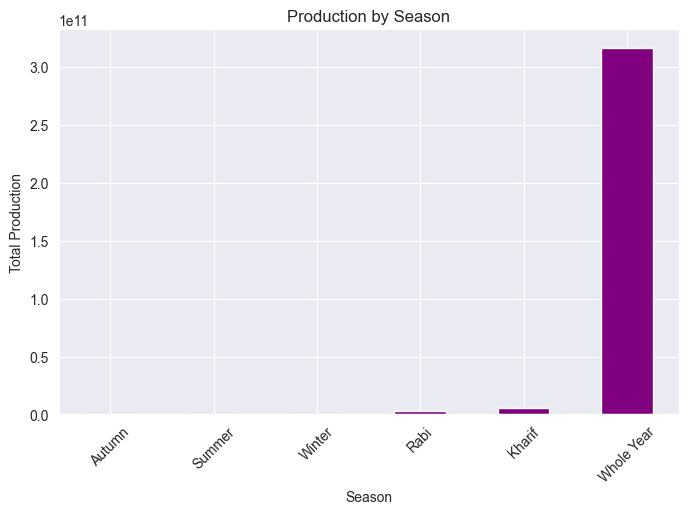

In [22]:
# Season-wise Production

season_prod = df_india.groupby('Season')['Production'].sum().sort_values()

plt.figure(figsize=(8,5))
season_prod.plot(kind='bar', color='purple')

plt.title("Production by Season")
plt.xlabel("Season")
plt.ylabel("Total Production")

plt.xticks(rotation=45)
plt.show()

### Yield Analysis (Productivity Insight)

Yield represents the production per unit area.  
This analysis highlights crops with the highest productivity, helping identify efficient farming outcomes.

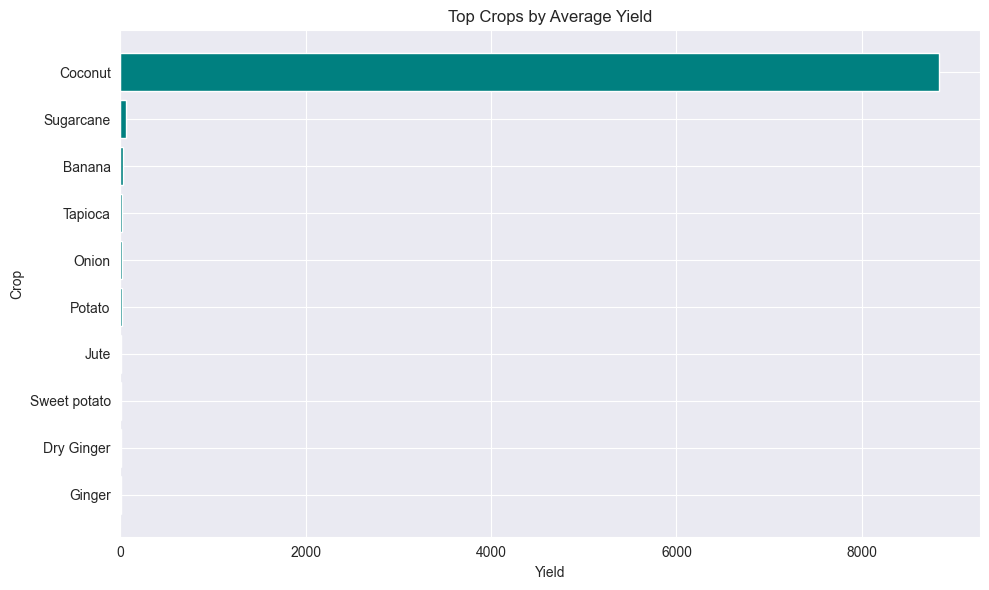

In [23]:
# Top Crops by Yield

df_india.columns = df_india.columns.str.strip()

top_yield = df_india.groupby('Crop')['Yield'].mean().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10,6))
plt.barh(top_yield.index, top_yield.values, color='teal')

plt.title("Top Crops by Average Yield")
plt.xlabel("Yield")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

### Area vs Production Relationship

This plot shows the relationship between cultivated area and production.  
It helps understand whether higher area leads to higher production.

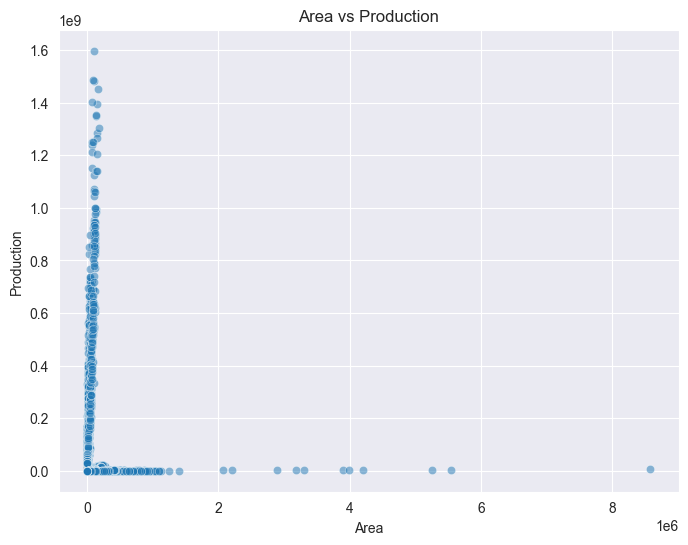

In [24]:
# Scatter Plot: Area vs Production

plt.figure(figsize=(8,6))

sns.scatterplot(x='Area', y='Production', data=df_india, alpha=0.5)

plt.title("Area vs Production")
plt.xlabel("Area")
plt.ylabel("Production")

plt.grid(True)
plt.show()

### Commodity Price Trend Analysis

This dataset represents the Minimum Support Price (MSP) of various crops over multiple years.  
The trend analysis helps in understanding how crop prices have increased over time.

This insight is useful for farmers to make economically beneficial crop decisions.

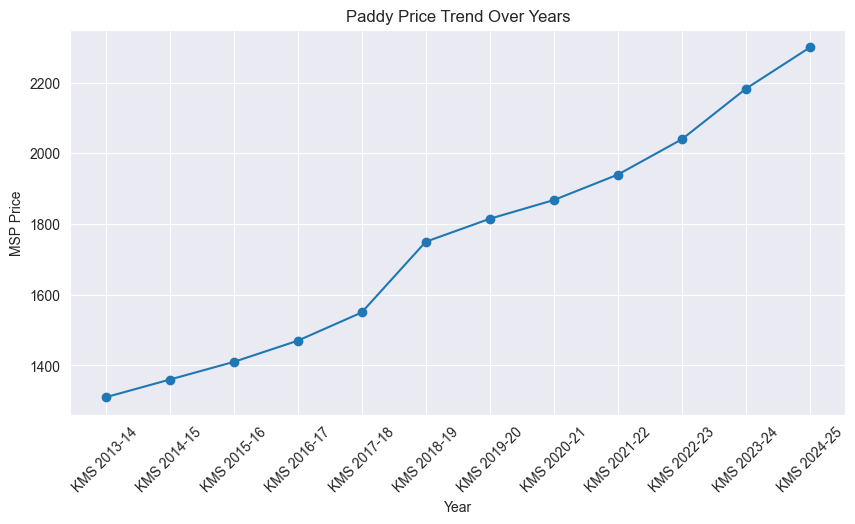

In [25]:
# Clean column names
df_market.columns = df_market.columns.str.strip()

# Select one crop (example: Paddy)
paddy = df_market[df_market['Commodities'] == 'Paddy (Common)']

# Extract year columns
years = paddy.columns[2:-1]  # skip Sl No and % column
prices = paddy.iloc[0][years]

plt.figure(figsize=(10,5))
plt.plot(years, prices, marker='o')

plt.title("Paddy Price Trend Over Years")
plt.xlabel("Year")
plt.ylabel("MSP Price")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Percentage Increase in Crop Prices

This visualization shows the percentage increase in MSP prices over time for different crops.  
It helps identify which crops have experienced the highest price growth.

This is important for economic decision-making in agriculture.

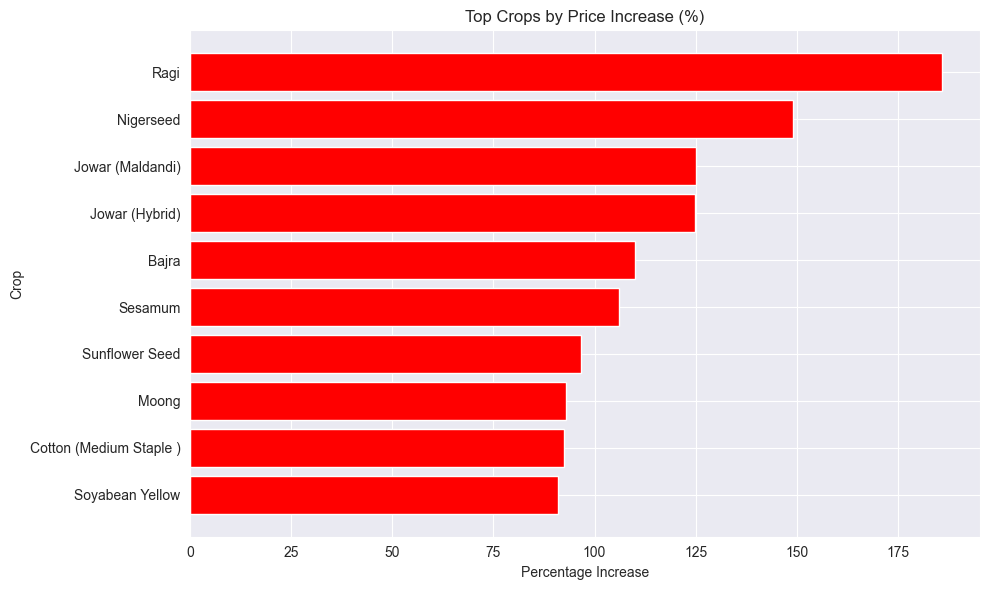

In [26]:
# Top crops by % increase

top_growth = df_market.sort_values(by='% increase 201314 to 2024-25', ascending=True).tail(10)

plt.figure(figsize=(10,6))
plt.barh(top_growth['Commodities'], top_growth['% increase 201314 to 2024-25'], color='red')

plt.title("Top Crops by Price Increase (%)")
plt.xlabel("Percentage Increase")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

### Highest Priced Crops (Latest Year)

This graph shows crops with the highest MSP in the latest year.  
It helps identify high-value crops for better economic decisions.

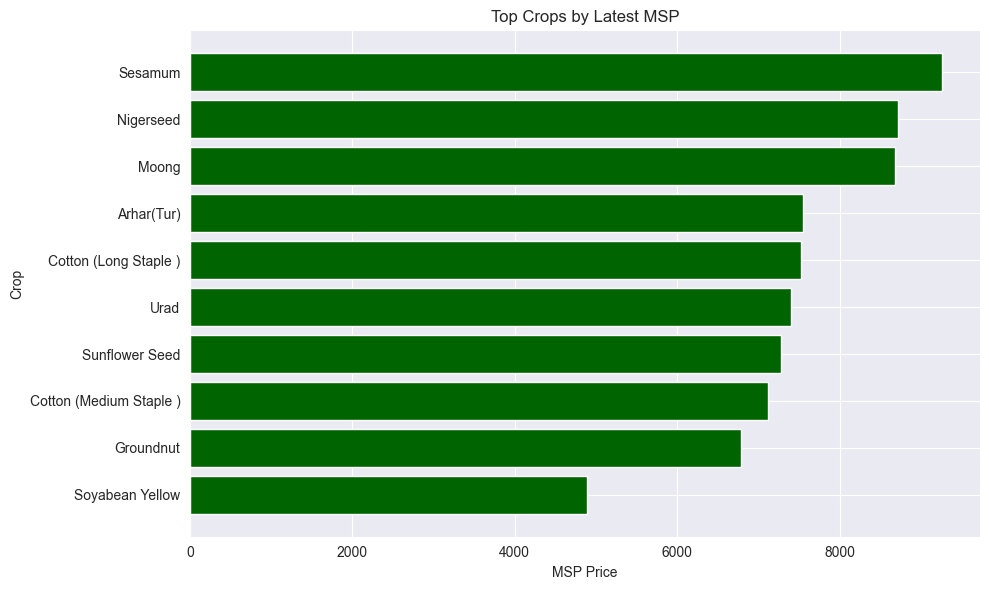

In [27]:
latest_year = 'KMS 2024-25'

top_prices = df_market.sort_values(by=latest_year, ascending=True).tail(10)

plt.figure(figsize=(10,6))
plt.barh(top_prices['Commodities'], top_prices[latest_year], color='darkgreen')

plt.title("Top Crops by Latest MSP")
plt.xlabel("MSP Price")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

### Price Stability Analysis

This analysis identifies crops with stable or fluctuating prices over time.  
Lower variation indicates stable pricing.

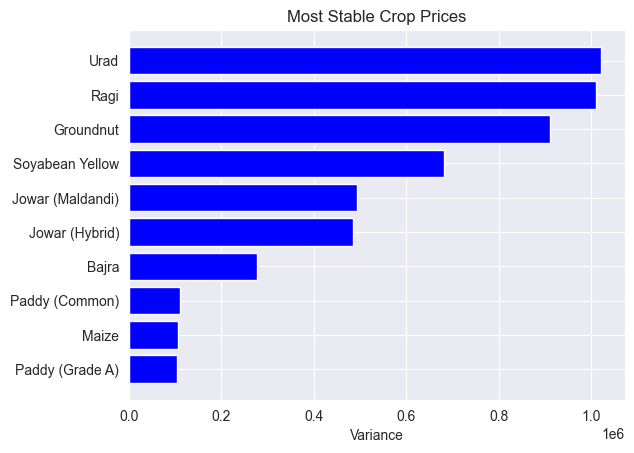

In [28]:
years = df_market.columns[2:-1]

df_market['Price_Variance'] = df_market[years].var(axis=1)

stable_crops = df_market.sort_values(by='Price_Variance').head(10)

plt.barh(stable_crops['Commodities'], stable_crops['Price_Variance'], color='blue')
plt.title("Most Stable Crop Prices")
plt.xlabel("Variance")
plt.show()

### Multi-Crop Price Comparison

This graph compares price trends of selected crops over time.

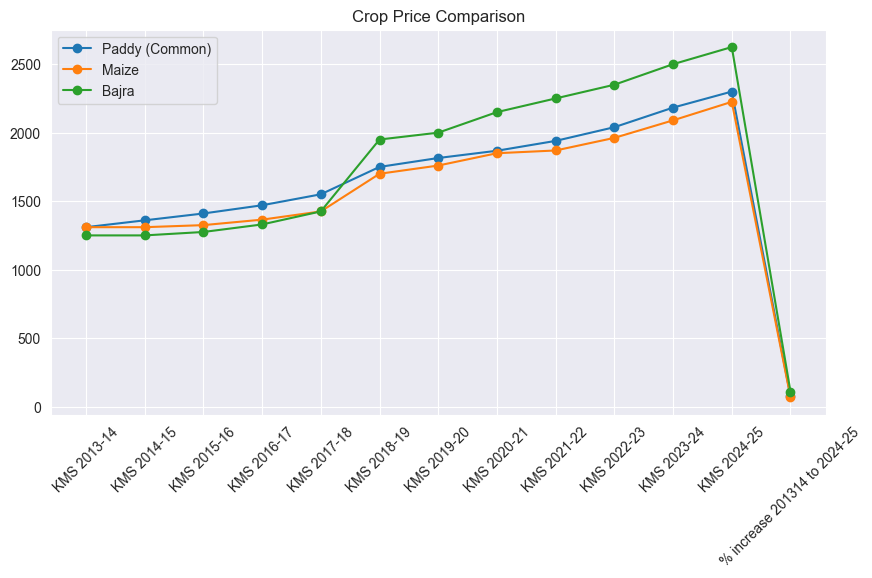

In [29]:
crops = ['Paddy (Common)', 'Maize', 'Bajra']

years = df_market.columns[2:-1]

plt.figure(figsize=(10,5))

for crop in crops:
    row = df_market[df_market['Commodities'] == crop]
    plt.plot(years, row.iloc[0][years], marker='o', label=crop)

plt.legend()
plt.title("Crop Price Comparison")
plt.xticks(rotation=45)
plt.show()

### Low vs High Growth Crops

This analysis compares crops with lowest and highest price increase.

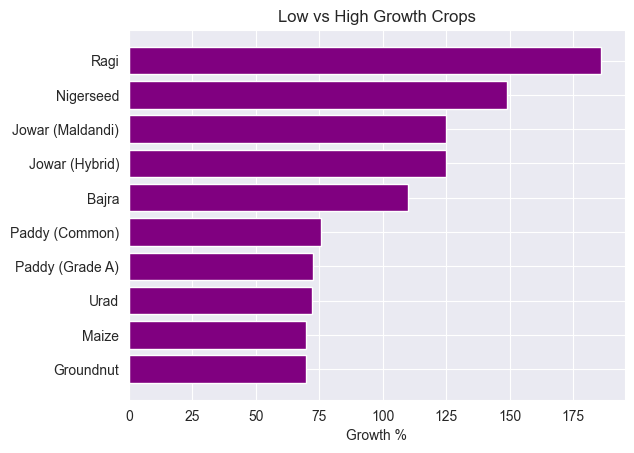

In [30]:
low_growth = df_market.sort_values(by='% increase 201314 to 2024-25').head(5)
high_growth = df_market.sort_values(by='% increase 201314 to 2024-25').tail(5)

combined = pd.concat([low_growth, high_growth])

plt.barh(combined['Commodities'], combined['% increase 201314 to 2024-25'], color='purple')
plt.title("Low vs High Growth Crops")
plt.xlabel("Growth %")
plt.show()

### Price Distribution Analysis

This plot shows distribution of MSP values across crops.

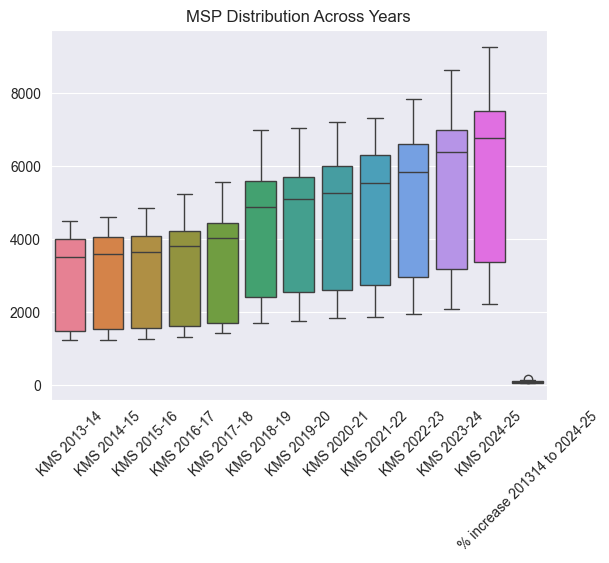

In [31]:
sns.boxplot(data=df_market[years])
plt.title("MSP Distribution Across Years")
plt.xticks(rotation=45)
plt.show()

### Crop Distribution in Uttar Pradesh and Uttarakhand

This pie chart shows the distribution of major crops based on total production in Uttar Pradesh and Uttarakhand.  
It helps identify which crops are most widely produced in these regions.

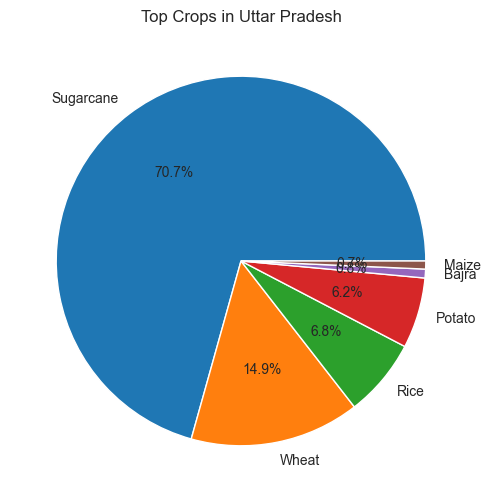

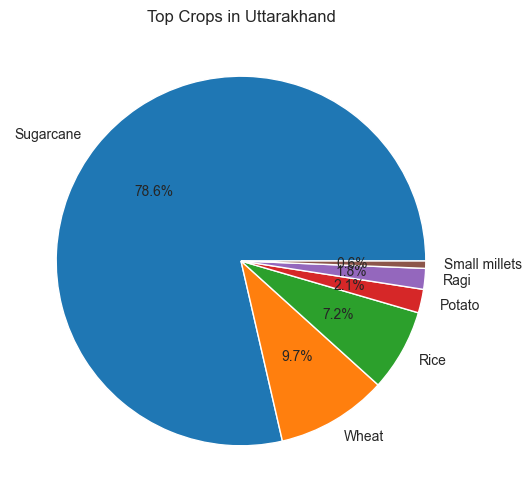

In [32]:
# Clean column names
df_india.columns = df_india.columns.str.strip()

# Filter data for UP and UK
states = ['Uttar Pradesh', 'Uttarakhand']
df_states = df_india[df_india['State'].isin(states)]

# Group by State and Crop
crop_prod = df_states.groupby(['State', 'Crop'])['Production'].sum().reset_index()

# Plot pie charts for each state
for state in states:
    data = crop_prod[crop_prod['State'] == state].sort_values(by='Production', ascending=False).head(6)
    
    plt.figure(figsize=(6,6))
    plt.pie(data['Production'], labels=data['Crop'], autopct='%1.1f%%')
    plt.title(f"Top Crops in {state}")
    plt.show()

### Top Crops Distribution in India

This pie chart shows the contribution of major crops to total agricultural production in India.

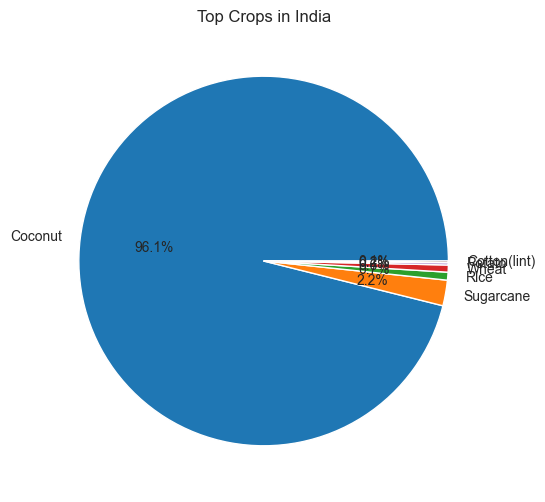

In [33]:
top_crops = df_india.groupby('Crop')['Production'].sum().sort_values(ascending=False).head(6)

plt.figure(figsize=(6,6))
plt.pie(top_crops.values, labels=top_crops.index, autopct='%1.1f%%')
plt.title("Top Crops in India")
plt.show()

### Crop Price Growth Analysis

This chart shows crops with the highest percentage increase in MSP over time.

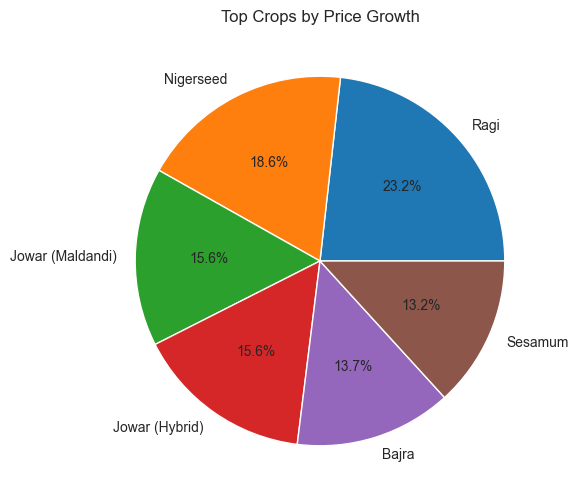

In [34]:
top_growth = df_market.sort_values(by='% increase 201314 to 2024-25', ascending=False).head(6)

plt.figure(figsize=(6,6))
plt.pie(top_growth['% increase 201314 to 2024-25'], 
        labels=top_growth['Commodities'], 
        autopct='%1.1f%%')

plt.title("Top Crops by Price Growth")
plt.show()

### Latest MSP Comparison

This chart compares the latest MSP values of major crops.

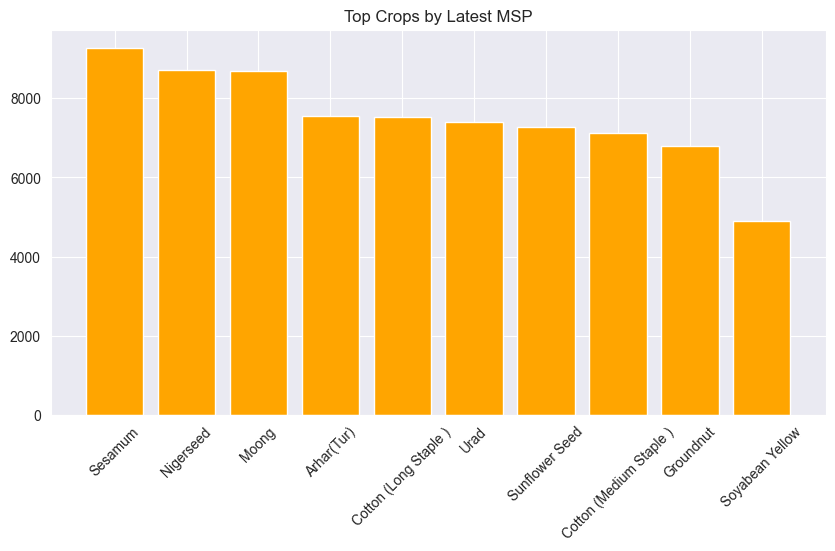

In [35]:
latest_year = 'KMS 2024-25'

top_msp = df_market.sort_values(by=latest_year, ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_msp['Commodities'], top_msp[latest_year], color='orange')

plt.xticks(rotation=45)
plt.title("Top Crops by Latest MSP")
plt.show()

### Data Splitting (Training and Testing)

The dataset is divided into features (input variables) and target (output variable).  
It is then split into training and testing sets to evaluate model performance.

Training data is used to train the model, while testing data is used to validate its accuracy.

In [36]:
# Features and Target

X = df_main.drop('label', axis=1)
y = df_main['label']

### Train-Test Split

The dataset is divided into training and testing sets using a 70-30 ratio.  
70% of the data is used for training the model, while 30% is used for testing its performance.

This ensures that the model is evaluated on unseen data and helps measure its generalization ability.

In [37]:
# Train-Test Split for Main Dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1540, 7)
Testing Data: (660, 7)


### Machine Learning Models

Different machine learning models are applied to predict the most suitable crop based on soil and environmental conditions.  
Multiple models are used to compare performance and select the best one.

The primary model used is Random Forest due to its high accuracy and ability to handle complex data.

### Logistic Regression

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create model
lr_model = LogisticRegression(max_iter=700)

# Train model
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Accuracy
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr) * 100:.2f}%")

Logistic Regression Accuracy: 95.15%


### Random Forest

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_rf) * 100
print(f"Random Forest Accuracy: {accuracy:.2f}%")

# Detailed report (VERY IMPORTANT)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 99.24%

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        34
      banana       1.00      1.00      1.00        26
   blackgram       1.00      1.00      1.00        26
    chickpea       1.00      1.00      1.00        34
     coconut       1.00      1.00      1.00        33
      coffee       1.00      1.00      1.00        30
      cotton       1.00      1.00      1.00        28
      grapes       1.00      1.00      1.00        23
        jute       0.87      1.00      0.93        34
 kidneybeans       1.00      1.00      1.00        36
      lentil       1.00      1.00      1.00        22
       maize       1.00      1.00      1.00        26
       mango       1.00      1.00      1.00        32
   mothbeans       1.00      1.00      1.00        34
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.00        24
      orange       1.00  

### Model Evaluation

The Random Forest model is evaluated using a confusion matrix and classification metrics such as precision, recall, and F1-score to assess its performance.

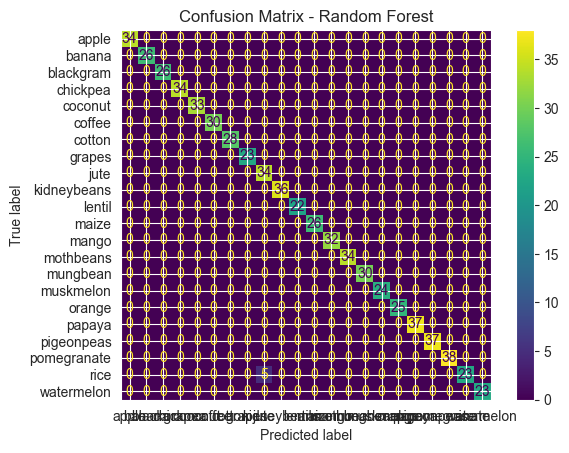

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Confusion Matrix - Random Forest")
plt.show()

### Cross Validation

Cross-validation is used to evaluate the model on multiple data splits.  
It helps ensure that the model is not overfitting and performs consistently on different subsets of data.

In [41]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)

print("Cross Validation Accuracy:", scores.mean()*100)

Cross Validation Accuracy: 99.4090909090909


### Feature Importance

Feature importance identifies which input features have the most influence on the model's predictions.  
This helps in understanding the key factors affecting crop recommendation.

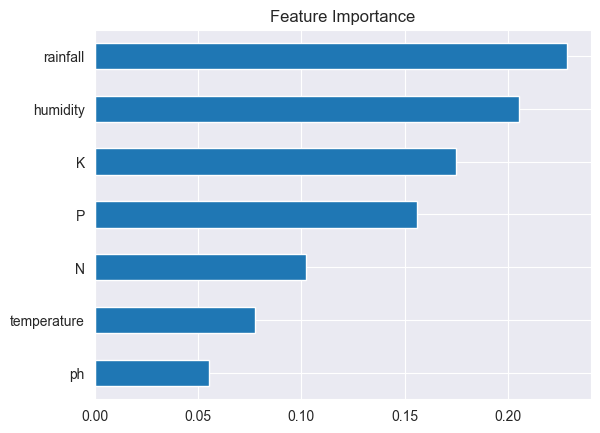

In [42]:
import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

### Support Vector Machine

In [43]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Create model
svm_model = SVC()

# Train model
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_svm) * 100
print(f"SVM Accuracy: {accuracy:.2f}%")

SVM Accuracy: 96.36%


KNN

In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train model
knn_model.fit(X_train, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_knn) * 100
print(f"KNN Accuracy: {accuracy:.2f}%")

KNN Accuracy: 97.73%


DECISION TREE

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create model
dt_model = DecisionTreeClassifier(criterion='gini', random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_dt) * 100
print(f"Decision Tree Accuracy: {accuracy:.2f}%")

Decision Tree Accuracy: 98.64%


### Model Performance Comparison

All supervised learning models are evaluated based on accuracy.  
The models are then ranked from best to worst to identify the most suitable model for crop prediction.

In [46]:
# Imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

# ==============================
# 1. Feature & Target
# ==============================
X = df_main.drop('label', axis=1)
y = df_main['label']

# ==============================
# 2. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ==============================
# 3. Train Models
# ==============================

# Logistic Regression
lr_model = LogisticRegression(max_iter=700)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# SVM
svm_model = SVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# ==============================
# 4. Model Comparison
# ==============================

results = {
    "Model": ["Logistic Regression", "Random Forest", "SVM", "KNN", "Decision Tree"],
    "Accuracy (%)": [
        accuracy_score(y_test, y_pred_lr) * 100,
        accuracy_score(y_test, y_pred_rf) * 100,
        accuracy_score(y_test, y_pred_svm) * 100,
        accuracy_score(y_test, y_pred_knn) * 100,
        accuracy_score(y_test, y_pred_dt) * 100
    ]
}

results_df = pd.DataFrame(results).sort_values(by="Accuracy (%)", ascending=False)

print("\n📊 Model Comparison (Best → Worst):\n")
print(results_df)

# Best Model
best = results_df.iloc[0]
print("\n🏆 Best Model:", best["Model"])
print("Accuracy:", f"{best['Accuracy (%)']:.2f}%")


📊 Model Comparison (Best → Worst):

                 Model  Accuracy (%)
1        Random Forest     99.242424
4        Decision Tree     98.636364
3                  KNN     97.727273
2                  SVM     96.363636
0  Logistic Regression     95.151515

🏆 Best Model: Random Forest
Accuracy: 99.24%


## Random Forest gives the highest accuracy here.

In [47]:
y_pred = rf_model.predict(X_test)
print(y_pred)  

['muskmelon' 'watermelon' 'papaya' 'papaya' 'apple' 'mango' 'apple'
 'mothbeans' 'mungbean' 'lentil' 'blackgram' 'coconut' 'pomegranate'
 'jute' 'coconut' 'pomegranate' 'apple' 'maize' 'papaya' 'muskmelon'
 'coffee' 'papaya' 'orange' 'papaya' 'chickpea' 'jute' 'mungbean' 'orange'
 'pigeonpeas' 'rice' 'pomegranate' 'mothbeans' 'jute' 'lentil' 'jute'
 'blackgram' 'jute' 'chickpea' 'chickpea' 'kidneybeans' 'papaya' 'mango'
 'blackgram' 'maize' 'mungbean' 'maize' 'pigeonpeas' 'coconut' 'muskmelon'
 'maize' 'blackgram' 'coffee' 'grapes' 'mungbean' 'coffee' 'kidneybeans'
 'cotton' 'apple' 'banana' 'blackgram' 'watermelon' 'coconut' 'lentil'
 'orange' 'papaya' 'pigeonpeas' 'orange' 'rice' 'muskmelon' 'pigeonpeas'
 'muskmelon' 'coconut' 'jute' 'banana' 'blackgram' 'papaya' 'banana'
 'cotton' 'watermelon' 'orange' 'coffee' 'chickpea' 'rice' 'mothbeans'
 'orange' 'mango' 'coffee' 'mothbeans' 'blackgram' 'pomegranate' 'maize'
 'mothbeans' 'cotton' 'papaya' 'pigeonpeas' 'mothbeans' 'kidneybeans'
 

In [48]:
X_test.head()

,N,P,K,temperature,humidity,ph,rainfall
1451,101,17,47,29.494014,94.729813,6.185053,26.308209
1334,98,8,51,26.179346,86.522581,6.259336,49.430510
1761,59,62,49,43.360515,93.351916,6.941497,114.778071
1735,44,60,55,34.280461,90.555616,6.825371,98.540477
1576,30,137,200,22.914300,90.704756,5.603413,118.604465


In [49]:
new_features = [[30, 135, 180, 20.66024, 84.3189, 6.3991, 114.9263]]

predicted_crop = rf_model.predict(new_features)

print("Predicted crop:", predicted_crop[0])

Predicted crop: grapes


### Unsupervised Learning (Clustering)

Unsupervised learning is applied to group similar data points without using labels.  
K-Means clustering is used to identify patterns in agricultural production data.

This helps in discovering hidden structures and similarities between crops and regions.

### Feature Selection

Only numerical features such as Area, Production, and Yield are selected for clustering.

In [50]:
features = ['Area', 'Production', 'Yield']

X_unsup = df_india[features]

print(X_unsup.head())

     Area  Production     Yield
0  1254.0      2061.0  1.643541
1  1258.0      2083.0  1.655803
2  1261.0      1525.0  1.209358
3  3100.0      5239.0  1.690000
4  3105.0      5267.0  1.696296


Handle Missing Values

In [51]:
X_unsup = X_unsup.dropna()

print("Shape after removing nulls:", X_unsup.shape)

Shape after removing nulls: (340414, 3)


### Feature Scaling

Standardization is applied to ensure all features contribute equally to clustering.

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsup)

### K-Means Clustering

K-Means algorithm is applied to group data into clusters based on similarity.

In [53]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels
df_cluster = X_unsup.copy()
df_cluster['Cluster'] = clusters

print(df_cluster.head())

     Area  Production     Yield  Cluster
0  1254.0      2061.0  1.643541        0
1  1258.0      2083.0  1.655803        0
2  1261.0      1525.0  1.209358        0
3  3100.0      5239.0  1.690000        0
4  3105.0      5267.0  1.696296        0


### Cluster Visualization

Clusters are visualized using Area and Production to observe grouping patterns.

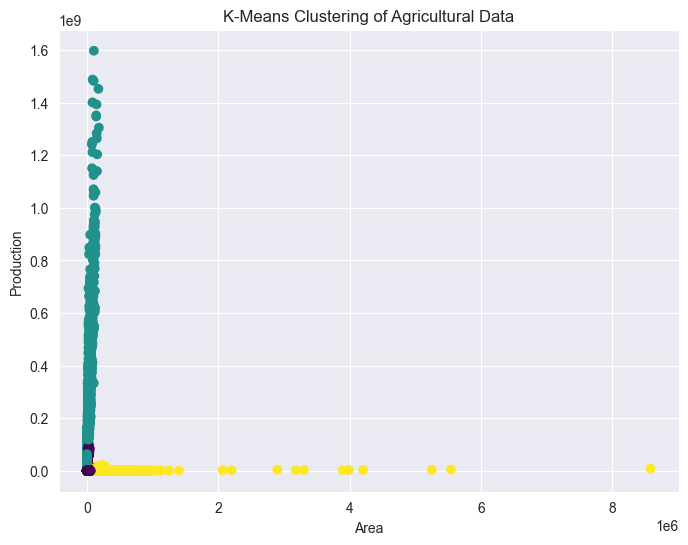

In [54]:
plt.figure(figsize=(8,6))

plt.scatter(X_unsup['Area'], X_unsup['Production'], 
            c=clusters, cmap='viridis')

plt.xlabel("Area")
plt.ylabel("Production")
plt.title("K-Means Clustering of Agricultural Data")

plt.show()

### DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering) groups data points based on density.  
It can identify clusters of arbitrary shape and also detect noise (outliers).

It is useful when clusters are not clearly separated.

In [58]:
from sklearn.cluster import DBSCAN
import pandas as pd

# Step 1: Take sample
sample_data = X_scaled[:5000]

# Step 2: Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_clusters = dbscan.fit_predict(sample_data)

# Step 3: Create DataFrame
df_dbscan = pd.DataFrame(sample_data)
df_dbscan['Cluster'] = db_clusters

# Step 4: Output
print(df_dbscan.head())

# Step 5: Cluster summary
print("\nCluster Counts:")
print(df_dbscan['Cluster'].value_counts())

          0         1         2  Cluster
0 -0.229190 -0.044418 -0.085484        0
1 -0.229103 -0.044417 -0.085470        0
2 -0.229038 -0.044443 -0.085954        0
3 -0.189168 -0.044270 -0.085433        0
4 -0.189060 -0.044269 -0.085426        0

Cluster Counts:
Cluster
 0    4868
 1      38
-1      36
 2      30
 3      21
 4       7
Name: count, dtype: int64


Visualization

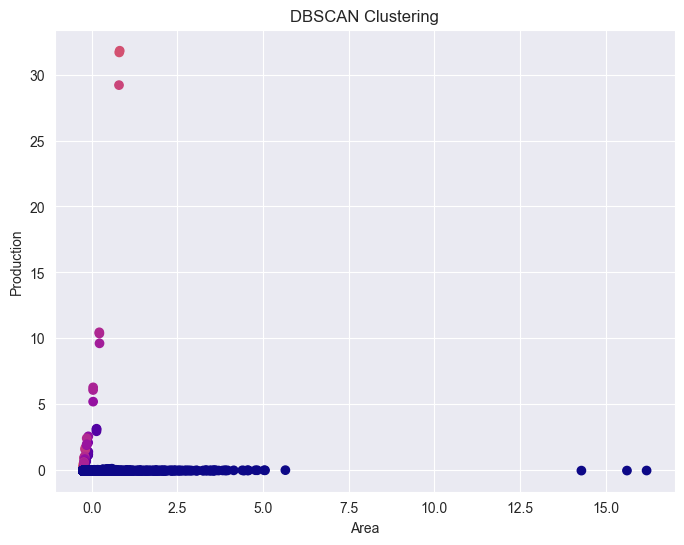

In [59]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_dbscan[0],
    df_dbscan[1],
    c=df_dbscan[2],
    cmap='plasma'
)

plt.title("DBSCAN Clustering")
plt.xlabel("Area")
plt.ylabel("Production")

plt.show()

In [60]:
import pickle

In [61]:
pickle.dump(rf_model, open("model.pkl", "wb"))